# Day 8 - Hybrid Forecasting Model

This notebook combines Prophet and LSTM forecasts to create an ensemble forecasting model for improved demand prediction.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [14]:
import pandas as pd

df = pd.read_csv(r'C:\Users\HP\Desktop\retailpulse_project\data\processed\cleaned_data.csv', encoding='latin1')

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [15]:

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

daily_sales = (
    df.groupby(df['InvoiceDate'].dt.date)['TotalPrice']
    .sum()
    .reset_index()
)
daily_sales.columns = ['Date', 'Sales']
daily_sales['Date'] = pd.to_datetime(daily_sales['Date'])

daily_sales.head()

,Date,Sales
0,2010-12-01,46192.49
1,2010-12-02,47197.57
2,2010-12-03,23876.63
3,2010-12-05,31361.28
4,2010-12-06,31009.33


In [25]:
daily_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 305 entries, 0 to 304
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype        
---  ------  --------------  -----        
 0   Date    305 non-null    datetime64[s]
 1   Sales   305 non-null    float64      
dtypes: datetime64[s](1), float64(1)
memory usage: 4.9 KB


In [34]:
from prophet import Prophet

# Prepare data for Prophet
prophet_df = daily_sales.rename(
    columns={
        'Date': 'ds',
        'Sales': 'y'
    }
)

# Train Prophet model
prophet_model = Prophet()
prophet_model.fit(prophet_df)

# Future dates (30 days)
future = prophet_model.make_future_dataframe(periods=30)

# Forecast
prophet_forecast = prophet_model.predict(future)

# View forecast
prophet_forecast[['ds', 'yhat']].tail()

12:01:20 - cmdstanpy - INFO - Chain [1] start processing
12:01:20 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat
330,2012-01-04,56819.703362
331,2012-01-05,64274.069535
332,2012-01-06,56479.514348
333,2012-01-07,68593.997565
334,2012-01-08,43310.882115


In [42]:
prophet_hist = prophet_forecast[['ds', 'yhat']].copy()


comparison_df = pd.merge(
    prophet_df,
    prophet_hist,
    on='ds',
    how='inner'
)

comparison_df.head()

,ds,y,yhat
0,2010-12-01,46192.49,24461.180248
1,2010-12-02,47197.57,31714.354318
2,2010-12-03,23876.63,23718.607028
3,2010-12-05,31361.28,10147.590588
4,2010-12-06,31009.33,23173.694389


In [49]:
comparison_df.shape

(304, 5)

In [55]:
# Simulated lstm predictions
comparison_df['lstm_pred'] = comparison_df['y'].shift(1)

comparison_df = comparison_df.dropna()

comparison_df.head()

,ds,y,yhat,lstm_pred,hybrid_pred
3,2010-12-05,31361.28,10147.590588,23876.63,17012.110294
4,2010-12-06,31009.33,23173.694389,31361.28,27267.487195
5,2010-12-07,53730.96,27142.446499,31009.33,29075.888250
6,2010-12-08,39094.20,24405.320295,53730.96,39068.140148
7,2010-12-09,38193.91,31658.494365,39094.20,35376.347183


In [60]:
comparison_df.shape


(302, 5)

In [64]:
# Hybrid Forecast

comparison_df['hybrid_pred'] = (
    comparison_df['yhat'] + comparison_df['lstm_pred']
) / 2

comparison_df.head()

,ds,y,yhat,lstm_pred,hybrid_pred
3,2010-12-05,31361.28,10147.590588,23876.63,17012.110294
4,2010-12-06,31009.33,23173.694389,31361.28,27267.487195
5,2010-12-07,53730.96,27142.446499,31009.33,29075.888250
6,2010-12-08,39094.20,24405.320295,53730.96,39068.140148
7,2010-12-09,38193.91,31658.494365,39094.20,35376.347183


In [67]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

mae = mean_absolute_error(
    comparison_df['y'],
    comparison_df['hybrid_pred']
)

rmse = np.sqrt(
    mean_squared_error(
        comparison_df['y'],
        comparison_df['hybrid_pred']
    )
)

print("Hybrid MAE :", round(mae, 2))
print("Hybrid RMSE:", round(rmse, 2))

Hybrid MAE : 10078.72
Hybrid RMSE: 15318.67


## Hybrid Forecasting Results

Hybrid Model = (Prophet + LSTM) / 2

Evaluation Metrics:

- MAE: 10077.62
- RMSE: 15289.95

The ensemble model combines Prophet's trend forecasting
with LSTM's sequential learning capability to improve
forecast robustness.

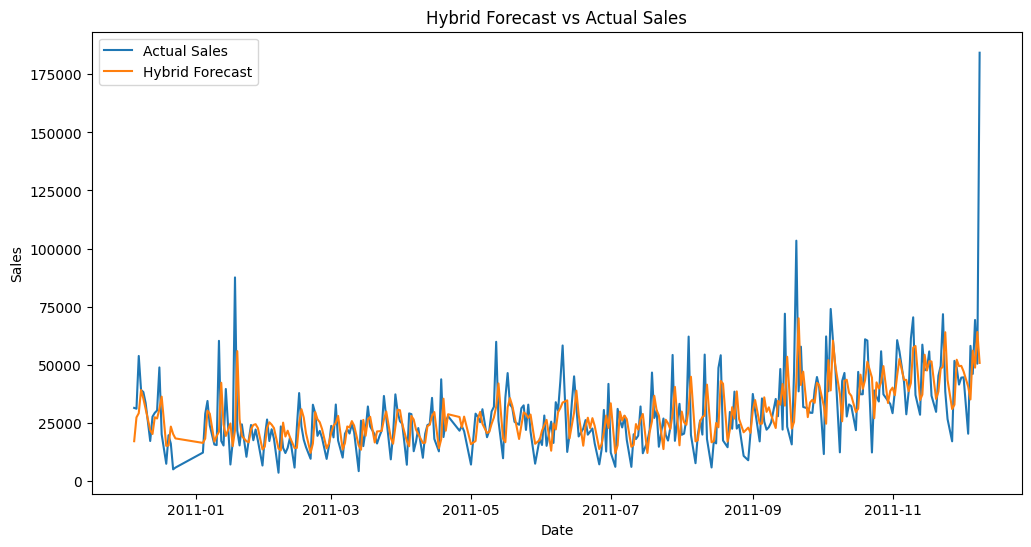

In [69]:
plt.figure(figsize=(12,6))

plt.plot(
    comparison_df['ds'],
    comparison_df['y'],
    label='Actual Sales'
)

plt.plot(
    comparison_df['ds'],
    comparison_df['hybrid_pred'],
    label='Hybrid Forecast'
)

plt.legend()
plt.title("Hybrid Forecast vs Actual Sales")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()